In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [2]:
# Đường dẫn tới tệp CSV
file_path = '../Data/btc-usd.csv'

# Đọc CSV, bỏ qua 2 hàng đầu (Ticker và Date NaN)
df = pd.read_csv(file_path, skiprows=2)

# Đặt tên cột thủ công (dựa trên cấu trúc file)
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Chuyển Date thành datetime và set làm index
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')  # Format ngày tháng kiểu MM/DD/YYYY
df.set_index('Date', inplace=True)

# Kiểm tra DataFrame sau xử lý (tùy chọn)
print(df.head())  # Nên hiển thị dữ liệu từ 2014-09-17
print(df.tail())  # Kiểm tra ngày cuối
df.info()  # Xem số hàng và kiểu dữ liệu

                 Close        High         Low        Open      Volume
Date                                                                  
2014-09-17  457.334015  468.174011  452.421997  465.864014  21056800.0
2014-09-18  424.440002  456.859985  413.104004  456.859985  34483200.0
2014-09-19  394.795990  427.834992  384.532013  424.102997  37919700.0
2014-09-20  408.903992  423.295990  389.882996  394.673004  36863600.0
2014-09-21  398.821014  412.425995  393.181000  408.084992  26580100.0
                  Close         High          Low         Open        Volume
Date                                                                        
2025-07-18  118003.2266  120851.9141  116925.9844  119284.1094  7.794580e+10
2025-07-19  117939.9766  118541.3984  117388.4141  117998.1250  4.756456e+10
2025-07-20  117300.7891  118865.0313  116550.1328  117944.1094  5.751545e+10
2025-07-21  117328.5300  119605.8100  116710.3400  117233.4800  7.020950e+10
2025-07-22  117419.6500  117928.3000  116

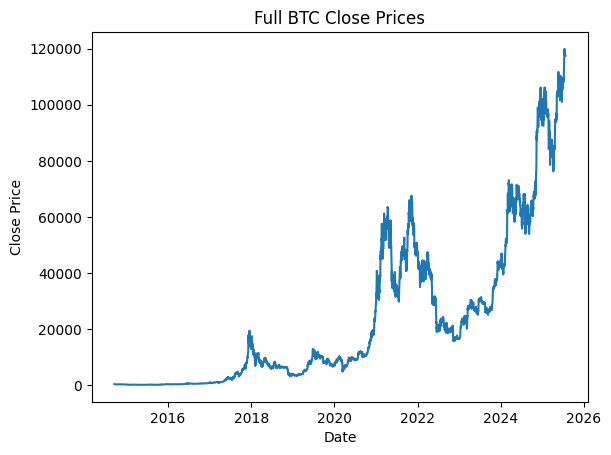

In [3]:
# Plot full dataset
plt.plot(df.index, df['Close'])
plt.title('Full BTC Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [4]:
# Tạo thư mục lưu kết quả và model
output_dir = '../'  # This points to the parent folder
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

output_dir_result = os.path.join(output_dir, 'Result/')
if not os.path.exists(output_dir_result):
    os.makedirs(output_dir_result, exist_ok=True)

output_dir_models = os.path.join(output_dir, 'Models/')
if not os.path.exists(output_dir_models):
    os.makedirs(output_dir_models, exist_ok=True)

In [5]:
# Split train/test với 90% train
to_row = int(len(df) * 0.8)
training_data = df[0:to_row]['Close']
testing_data = df[to_row:]['Close']
training_data, testing_data

(Date
 2014-09-17      457.334015
 2014-09-18      424.440002
 2014-09-19      394.795990
 2014-09-20      408.903992
 2014-09-21      398.821014
                   ...     
 2023-05-17    27398.802730
 2023-05-18    26832.208980
 2023-05-19    26890.128910
 2023-05-20    27129.585940
 2023-05-21    26753.826170
 Name: Close, Length: 3169, dtype: float64,
 Date
 2023-05-22     26851.27734
 2023-05-23     27225.72656
 2023-05-24     26334.81836
 2023-05-25     26476.20703
 2023-05-26     26719.29102
                   ...     
 2025-07-18    118003.22660
 2025-07-19    117939.97660
 2025-07-20    117300.78910
 2025-07-21    117328.53000
 2025-07-22    117419.65000
 Name: Close, Length: 793, dtype: float64)

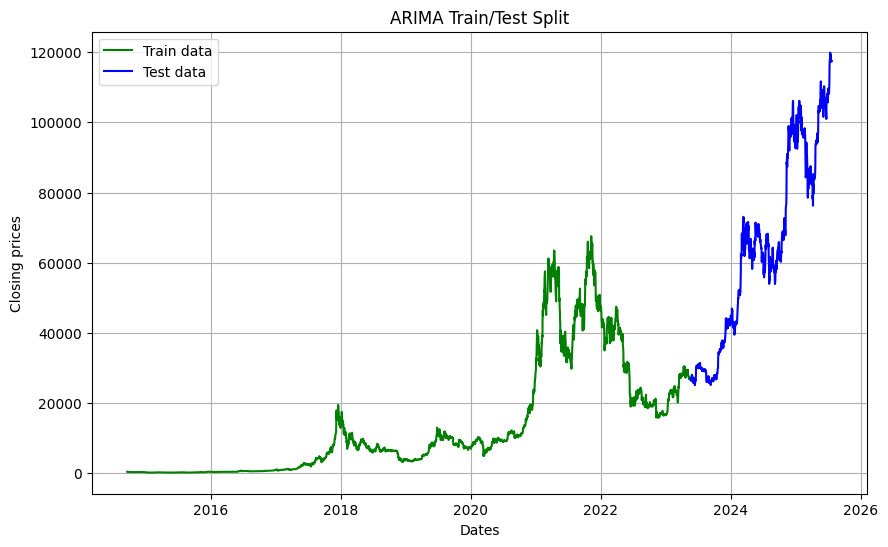

In [6]:
# Plot train/test split
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing prices')
plt.plot(training_data, 'green', label='Train data')
plt.plot(testing_data, 'blue', label='Test data')
plt.legend()
plt.title('ARIMA Train/Test Split')

# Save plot
plt.savefig(os.path.join(output_dir_result, 'arima_train_test_split.png'), dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Rolling forecast
model_predictions = []
n_test_obser = len(testing_data)

for i in range(n_test_obser):
    model = ARIMA(training_data, order=(4,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output.iloc[0]
    model_predictions.append(yhat)
    actual_test_value = testing_data.iloc[i]
    training_data = pd.concat([training_data, pd.Series([actual_test_value], index=[testing_data.index[i]])])
    print(output)

c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2023-05-22    26748.392753
Freq: D, dtype: float64
2023-05-23    26852.746089
Freq: D, dtype: float64


c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\P

2023-05-24    27217.066845
Freq: D, dtype: float64


c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


...

c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\P

2025-07-19    118042.316514
Freq: D, dtype: float64
2025-07-20    117950.904074
Freq: D, dtype: float64


c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\P

2025-07-21    117338.866374
Freq: D, dtype: float64
2025-07-22    117296.156532
Freq: D, dtype: float64


c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\VincentPham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


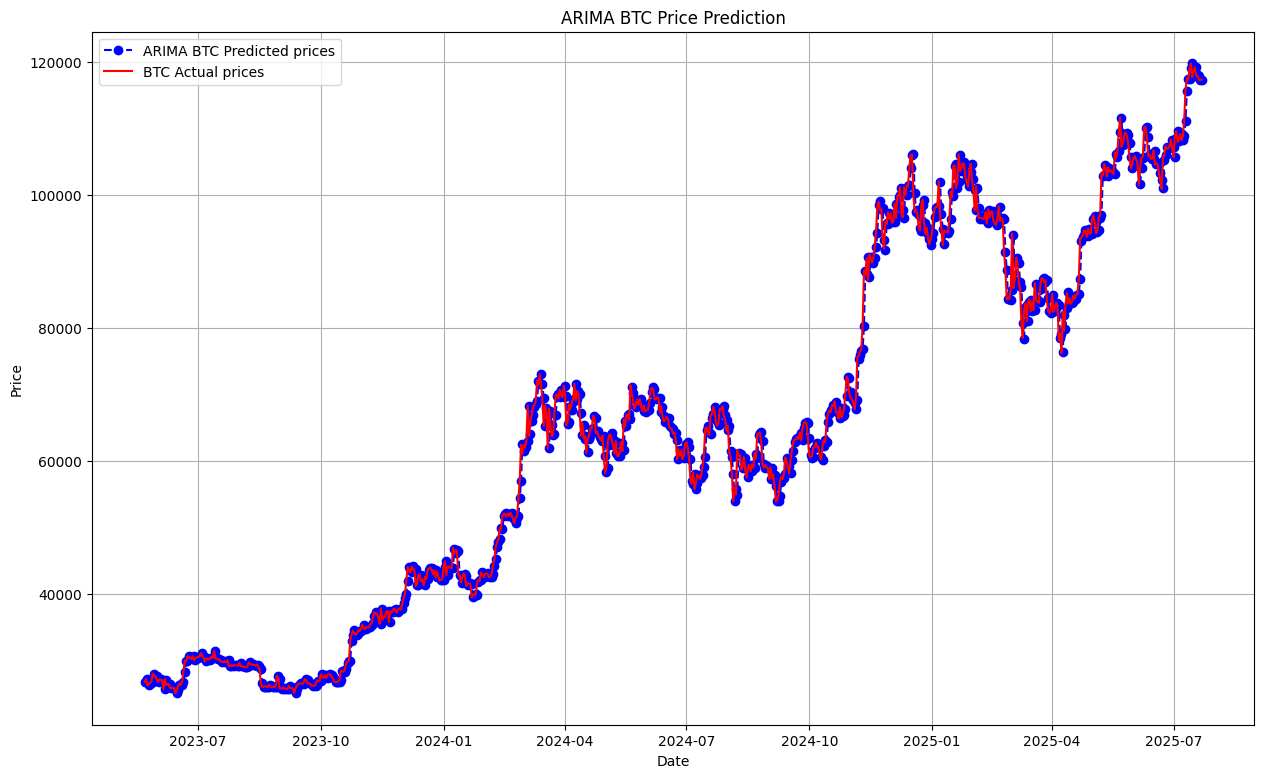

In [8]:
# Vẽ plot prediction
plt.figure(figsize=(15,9))
plt.grid()

data_range = df[to_row:].index

plt.plot(data_range, model_predictions, color='blue', marker='o', linestyle='dashed', label='ARIMA BTC Predicted prices')
plt.plot(data_range, testing_data, color='red', label='BTC Actual prices')

plt.title('ARIMA BTC Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

# Save plot vào output_dir_result
plt.savefig(os.path.join(output_dir_result, 'arima_btc_price_prediction.png'), dpi=300, bbox_inches='tight')
plt.show()

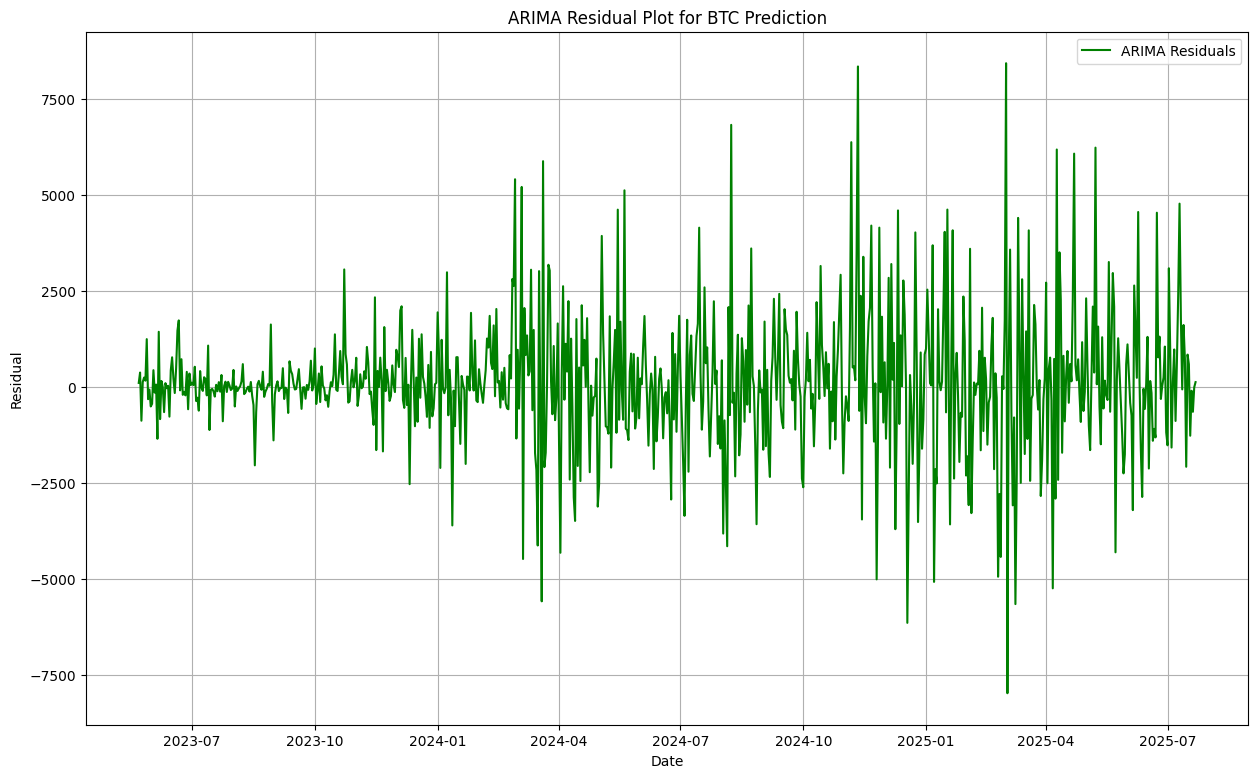

In [9]:
# Tính residuals
residuals = testing_data - model_predictions

# Vẽ residual plot
plt.figure(figsize=(15,9))
plt.grid()

plt.plot(data_range, residuals, color='green', label='ARIMA Residuals')

plt.title('ARIMA Residual Plot for BTC Prediction')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()

# Save plot vào output_dir_result
plt.savefig(os.path.join(output_dir_result, 'arima_btc_residual_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Tính metrics
mape = np.mean(np.abs(testing_data - model_predictions) / np.abs(testing_data))  # MAPE thủ công
mae = mean_absolute_error(testing_data, model_predictions)
mse = mean_squared_error(testing_data, model_predictions)
rmse = math.sqrt(mse)

# Tạo DataFrame so sánh
results_df = pd.DataFrame({
    'Date': data_range,
    'Predicted': model_predictions,
    'Actual': testing_data
})

# Thêm metrics vào DataFrame
results_df['MAPE'] = mape
results_df['MAE'] = mae
results_df['MSE'] = mse
results_df['RMSE'] = rmse

# Save CSV vào output_dir_result
results_df.to_csv(os.path.join(output_dir_result, 'arima_btc_predictions_and_metrics.csv'), index=False)

# In metrics để kiểm tra
print('ARIMA Mean Absolute Percentage Error:', mape)
print('ARIMA Mean Squared Error:', mse)
print('ARIMA Root Mean Squared Error:', rmse)
print('ARIMA Mean Absolute Error:', mae)

ARIMA Mean Absolute Percentage Error: 0.01734613567062663
ARIMA Mean Squared Error: 2973597.7208554912
ARIMA Root Mean Squared Error: 1724.4122827373653
ARIMA Mean Absolute Error: 1138.8722387801247


In [11]:
# Save model vào output_dir_models (lưu model_fit cuối cùng từ loop)
joblib.dump(model_fit, os.path.join(output_dir_models, 'arima_btc_model.pkl'))
print("ARIMA model saved successfully.")

ARIMA model saved successfully.
